In [1]:
# ============================================================
# Notebook 3: Model Evaluation and Business Recommendations
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

In [3]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

models = {
    "Logistic Regression": joblib.load("../models/logistic_regression_pipeline.pkl"),
    "Random Forest": joblib.load("../models/random_forest_pipeline.pkl"),
    "XGBoost": joblib.load("../models/xgboost_pipeline.pkl"),
    "CatBoost": joblib.load("../models/catboost_pipeline.pkl")
}

# Model Evaluation and Business Insights

This notebook evaluates the selected churn prediction model from a business decision-making perspective. Instead of relying only on default classification metrics, the analysis focuses on threshold selection, precision–recall trade-offs, customer risk segmentation, and retention recommendations.

## Model Selection

In [4]:
def evaluate_loaded_model(model, X_test, y_test, model_name):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.50).astype(int)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    }


model_selection_results = []

for name, model in models.items():
    model_selection_results.append(
        evaluate_loaded_model(model, X_test, y_test, name)
    )

model_selection_df = pd.DataFrame(model_selection_results)

model_selection_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.738,0.504,0.783,0.614,0.842,0.633
1,Random Forest,0.757,0.528,0.794,0.635,0.843,0.652
2,XGBoost,0.798,0.648,0.527,0.581,0.842,0.652
3,CatBoost,0.808,0.671,0.540,0.599,0.845,0.662


Although CatBoost achieved the highest ROC-AUC and PR-AUC, the difference compared with Random Forest was marginal. Random Forest achieved the highest recall and F1-score, making it more suitable for a retention use case where missing potential churners is costly.

For this reason, Random Forest is selected for detailed business evaluation.

In [5]:
final_model_name = "Random Forest"
final_model = models[final_model_name]

y_proba = final_model.predict_proba(X_test)[:, 1]

## Threshold optimization

In [9]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.head()

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.479773,0.336670,0.989305,0.502376
1,0.15,0.515969,0.351638,0.975936,0.516997
2,0.20,0.576295,0.382011,0.965241,0.547384
3,0.25,0.627395,0.411902,0.943850,0.573517
4,0.30,0.655784,0.429658,0.906417,0.582975


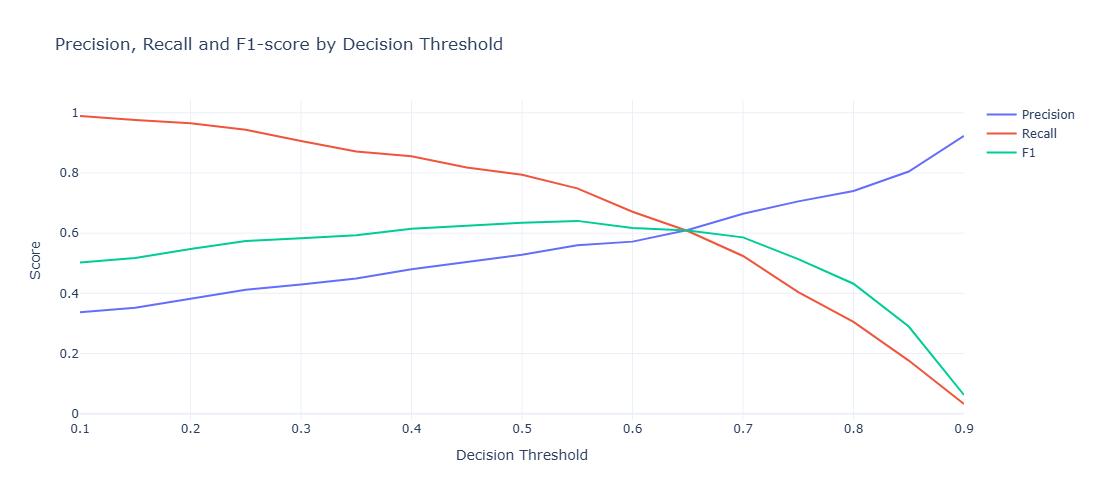

In [10]:
fig = go.Figure()

for metric in ["Precision", "Recall", "F1"]:
    fig.add_trace(
        go.Scatter(
            x=threshold_df["Threshold"],
            y=threshold_df[metric],
            mode="lines",
            name=metric
        )
    )

fig.update_layout(
    title="Precision, Recall and F1-score by Decision Threshold",
    xaxis_title="Decision Threshold",
    yaxis_title="Score",
    template="plotly_white",
    width=950,
    height=500
)

fig.show()

In [14]:
target_recall = 0.85

eligible_thresholds = threshold_df[
    threshold_df["Recall"] >= target_recall
].copy()

best_row = eligible_thresholds.sort_values(
    "Precision",
    ascending=False
).iloc[0]

best_threshold = best_row["Threshold"]

best_row

Threshold    0.400000
Accuracy     0.715401
Precision    0.479760
Recall       0.855615
F1           0.614793
Name: 6, dtype: float64

The decision threshold was selected using a business-oriented rule: maintain recall above the target level while maximizing precision. This ensures the model identifies a large share of churners while limiting unnecessary retention actions.

## Final Metrics

In [15]:
y_pred_final = (y_proba >= best_threshold).astype(int)

final_metrics = pd.DataFrame([{
    "Model": final_model_name,
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1": f1_score(y_test, y_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba)
}])

final_metrics.round(3)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.4,0.715,0.48,0.856,0.615,0.843,0.652


## Confusion Matrix

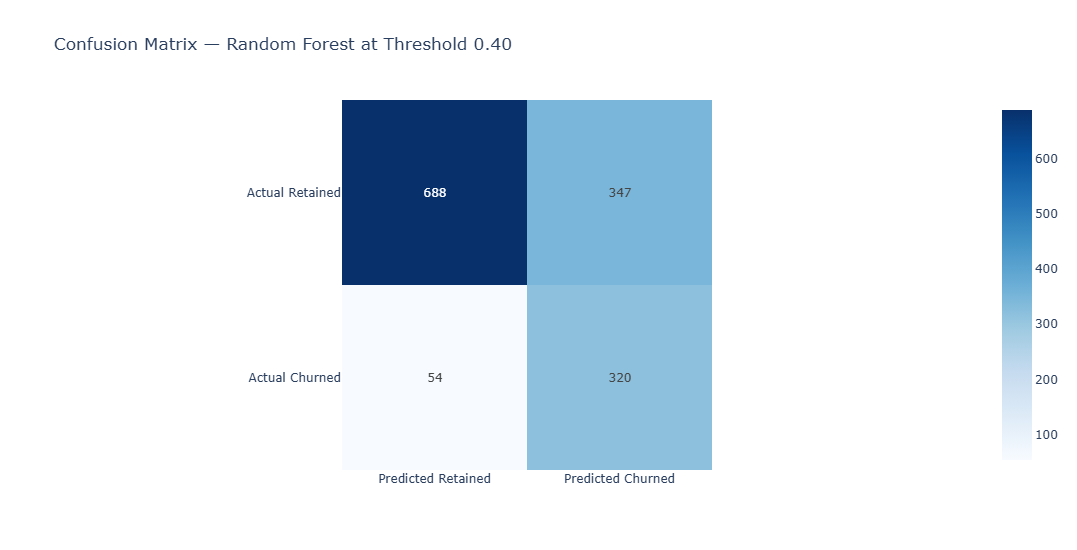

,Predicted Retained,Predicted Churned
Actual Retained,688,347
Actual Churned,54,320


In [16]:
cm = confusion_matrix(y_test, y_pred_final)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Retained", "Actual Churned"],
    columns=["Predicted Retained", "Predicted Churned"]
)

fig = px.imshow(
    cm_df,
    text_auto=True,
    color_continuous_scale="Blues",
    title=f"Confusion Matrix — {final_model_name} at Threshold {best_threshold:.2f}"
)

fig.update_layout(
    template="plotly_white",
    width=650,
    height=550
)

fig.show()

cm_df

The confusion matrix translates model performance into business decisions. False negatives represent customers who churned but were not identified by the model, while false positives represent customers who would receive a retention action despite not churning.

## Risk Segmentation

In [17]:
risk_df = X_test.copy()
risk_df["actual_churn"] = y_test.values
risk_df["churn_probability"] = y_proba

risk_df["risk_segment"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

risk_summary = (
    risk_df
    .groupby("risk_segment")
    .agg(
        customers=("churn_probability", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        actual_churn_rate=("actual_churn", "mean")
    )
    .reset_index()
)

risk_summary["avg_churn_probability"] *= 100
risk_summary["actual_churn_rate"] *= 100

risk_summary.round(2)

,risk_segment,customers,avg_churn_probability,actual_churn_rate
0,Low,620,12.44,5.65
1,Medium,350,44.82,25.14
2,High,285,69.94,48.07
3,Very High,154,85.46,74.03


## Customer Risk Segmentation

| Risk Segment | Churn Probability | Recommended Action |
|-------------|------------------:|--------------------|
| Very High | > 80% | Immediate retention call or personalized offer |
| High | 60–80% | Targeted discount or contract upgrade |
| Medium | 30–60% | Automated email campaign or proactive support |
| Low | < 30% | No immediate intervention |

# Business Recommendations

The churn model should be used as a customer prioritization tool rather than only as a binary classifier.

Customers can be ranked by predicted churn probability and assigned to different retention strategies based on risk level. High-risk customers should receive personalized, higher-cost interventions, while medium-risk customers can be targeted through lower-cost automated campaigns.

This approach helps the business allocate retention resources more efficiently and move from reactive churn analysis to proactive churn prevention.